<a href="https://colab.research.google.com/github/NataliiaFakas/TFG_BMW/blob/main/4_Train_Dev_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Construcción del dataset definitivo**

---

# Introducción

A lo largo de este cuaderno, se construirá el dataset definitivo mediante la función `añadir_variables_macro`, que combinará las ventas anuales de BMW con las variables macroeconómicas `Compensation_Per_Employee`, `Industrial_Production`, `Population_Total` y `EUR_USD` seleccionadas en el análisis de importancia utilizando Random Forest.

El resultado obtenido será un conjunto de datos de 21 observaciones (2005-2025) y 6 columnas (año, variable objetivo y cuatro predictores), que constituye la base sobre la que se entrenará y evaluará el modelo predictivo.

In [2]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

ruta_macro = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"
ruta_bmw = "/content/drive/MyDrive/TFG_BMW/datasets/ventas_bmw.csv"

df_macro = pd.read_csv(ruta_macro)
df_bmw = pd.read_csv(ruta_bmw)

display(df_macro.head())
display(df_bmw.head())

Mounted at /content/drive


,Year,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total
0,2005,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887
1,2006,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018
2,2007,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477
3,2008,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280
4,2009,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898


,Año,Ventas_BMW_Unidades
0,2005,1126768
1,2006,1185088
2,2007,1276793
3,2008,1202239
4,2009,1068770


# Función `variables_modelo`

---

🔧 **Reutilizaremos esta función cada vez que se entrene un nuevo modelo para incorporar al conjunto de datos de ventas de BMW**, las variables macroeconómicas seleccionadas utilizando el año como clave de unión.

In [3]:
def añadir_variables_macro(df_bmw, df_macro):

    df_final = df_bmw.merge(
        df_macro[variables_modelo],
        on="Year",
        how="left"
    )

    return df_final

In [4]:
variables_modelo = [
    "Year",
    "Compensation_Per_Employee",
    "Industrial_Production",
    "Population_Total",
    "EUR_USD"
]

df_macro_reducido = df_macro[variables_modelo]

df_macro_reducido.head()

,Year,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD
0,2005,31.22,153.2,434585887,1.2441
1,2006,31.95,147.7,436041018,1.2556
2,2007,32.75,145.5,437514477,1.3705
3,2008,33.86,148.0,439074280,1.4708
4,2009,34.41,144.5,440467898,1.3948


In [5]:
df_bmw_filtrado = df_bmw.rename(columns={"Año": "Year"})

data = añadir_variables_macro(df_bmw_filtrado, df_macro_reducido)

display(data.head())
print("Shape del dataset definitivo:", data.shape)

,Year,Ventas_BMW_Unidades,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD
0,2005,1126768,31.22,153.2,434585887,1.2441
1,2006,1185088,31.95,147.7,436041018,1.2556
2,2007,1276793,32.75,145.5,437514477,1.3705
3,2008,1202239,33.86,148.0,439074280,1.4708
4,2009,1068770,34.41,144.5,440467898,1.3948


Shape del dataset definitivo: (21, 6)


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42  # semilla fija para reproducibilidad

X = data.drop(columns=["Year", "Ventas_BMW_Unidades"])
y = data["Ventas_BMW_Unidades"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21, 4)
y shape: (21,)


## Partición del conjunto de datos: train / dev / test

---

Con el objetivo de simular un escenario de despliegue en producción, el conjunto de datos se divide aleatoriamente en tres subconjuntos independientes:

- **Train (70 %)**: utilizado para el entrenamiento de los parámetros del modelo.
- **Dev (15 %)**: utilizado para la optimización de los hiperparámetros.
- **Test (15 %)**: utilizado únicamente para la evaluación final, simulando datos no vistos durante el desarrollo del modelo.

La partición se realiza mediante un muestreo aleatorio con una semilla fija (`random_state = 42`), lo que garantiza la reproducibilidad de los resultados y de los experimentos posteriores.

Dado el reducido tamaño de la muestra (21 observaciones), la partición 70/15/15 se traduce en 14 observaciones de train, 3 de dev y 4 de test. Este tamaño muestral tan limitado, especialmente en los conjuntos de dev y test, debe tenerse en cuenta a la hora de interpretar los resultados obtenidos en los siguientes apartados, ya que estimaciones basadas en muestras tan pequeñas presentan una elevada varianza. Por lo que los resultados podrían cambiar mucho si cambian las observaciones.

In [7]:
# --- Partición train (70%) / dev (15%) / test (15%) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, shuffle=True
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Dev:   {X_dev.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 14 muestras
Dev:   3 muestras
Test:  4 muestras


## Optimización de hiperparámetros

---

Se realiza una grid search o búsqueda en rejilla, sobre dos hiperparámetros del `RandomForestRegressor`:

- **`n_estimators`**: número de árboles que componen el bosque.
- **`min_impurity_decrease`**: decremento mínimo de impureza exigido para realizar una división (*split*) en un árbol. Al tratarse de un problema de regresión, la impureza se mide en términos de error cuadrático medio, por lo que este hiperparámetro se expresa en la misma escala que la variable objetivo al cuadrado.

Para cada combinación de valores del grid, el modelo se entrena sobre el conjunto de train y se evalúa sobre el conjunto de dev mediante el error cuadrático medio (MSE), manteniendo fijo el `random_state` en todas las combinaciones para asegurar la reproducibilidad del experimento. La combinación seleccionada será aquella que minimice el MSE en dev.

In [8]:
n_estimators_grid = [10, 25, 50, 100, 200, 300]
min_impurity_decrease_grid = [0.0, 1e6, 5e6, 1e7, 5e7, 1e8]

resultados = []
for n_est in n_estimators_grid:
    for mid in min_impurity_decrease_grid:
        modelo = RandomForestRegressor(
            n_estimators=n_est,
            min_impurity_decrease=mid,
            random_state=RANDOM_STATE
        )
        modelo.fit(X_train, y_train)
        pred_dev = modelo.predict(X_dev)
        mse_dev = mean_squared_error(y_dev, pred_dev)
        resultados.append({
            "n_estimators": n_est,
            "min_impurity_decrease": mid,
            "MSE_dev": mse_dev
        })

df_resultados = pd.DataFrame(resultados).sort_values("MSE_dev")
display(df_resultados.head(10))

,n_estimators,min_impurity_decrease,MSE_dev
0,10,0.0,5.724120e+09
1,10,1000000.0,5.724120e+09
2,10,5000000.0,5.724120e+09
3,10,10000000.0,5.724120e+09
4,10,50000000.0,5.753907e+09
5,10,100000000.0,5.767147e+09
35,300,100000000.0,7.715352e+09
30,300,0.0,7.826314e+09
32,300,5000000.0,7.826344e+09
31,300,1000000.0,7.826344e+09


### Interpretación del barrido de hiperparámetros

---

Los resultados muestran que el MSE en dev no disminuye de forma monótona al aumentar `n_estimators`. La configuración con menor error corresponde a`n_estimators` = 10, mientras que algunas configuraciones con un mayor número de árboles presentan un MSE superior.

Este comportamiento no implica necesariamente que utilizar un mayor número de árboles empeore el modelo de forma general. El parámetro `n_estimators` controla el número de árboles utilizados para construir el bosque y, al aumentarlo, se espera principalmente una mayor estabilidad de las predicciones, no una reducción necesariamente monótona del error. En este caso, además, la evaluación se realiza sobre un conjunto de dev de únicamente 3 observaciones, por lo que el MSE puede ser muy sensible a las predicciones realizadas sobre cada una de ellas. Por este motivo, las diferencias observadas entre configuraciones deben interpretarse con cautela y no como evidencia concluyente de que un determinado número de árboles generalice mejor que otro.

Por otro lado, se observa que min_impurity_decrease apenas modifica el MSE en dev para los valores más bajos del grid. El efecto comienza a apreciarse con valores del orden de 5·10⁷–10⁸, donde el hiperparámetro empieza a limitar determinadas divisiones de los árboles y, por tanto, a actuar como mecanismo de regularización. Esto es coherente con la escala de la variable objetivo y con la magnitud de las reducciones de impureza que se producen durante la construcción de los árboles.

In [9]:
mejor = df_resultados.iloc[0]
print(f"Mejor combinación -> n_estimators={int(mejor['n_estimators'])}, "
      f"min_impurity_decrease={mejor['min_impurity_decrease']}, "
      f"MSE_dev={mejor['MSE_dev']:.2f}")

Mejor combinación -> n_estimators=10, min_impurity_decrease=0.0, MSE_dev=5724119738.17


### Selección de la combinación óptima

La combinación que minimiza el MSE en dev es `n_estimators = 10` y `min_impurity_decrease = 0.0`, con un MSE de 5.724.119.738,17.

No obstante, esta selección debe interpretarse con cautela. El conjunto de dev contiene únicamente 3 observaciones, por lo que una diferencia en las predicciones de una sola observación puede modificar considerablemente el MSE. En consecuencia, el resultado identifica la mejor combinación dentro de esta partición concreta, pero no proporciona evidencia suficiente para afirmar que un bosque de 10 árboles sea realmente superior a configuraciones con un mayor número de árboles en términos de capacidad de generalización.

### Visualización del efecto de los hiperparámetros

---

Con el fin de analizar de forma conjunta el efecto de ambos hiperparámetros sobre el error en dev, se representa un mapa de calor (*heatmap*) con el MSE en dev para cada combinación de `n_estimators` y `min_impurity_decrease` evaluada en la búsqueda en rejilla.

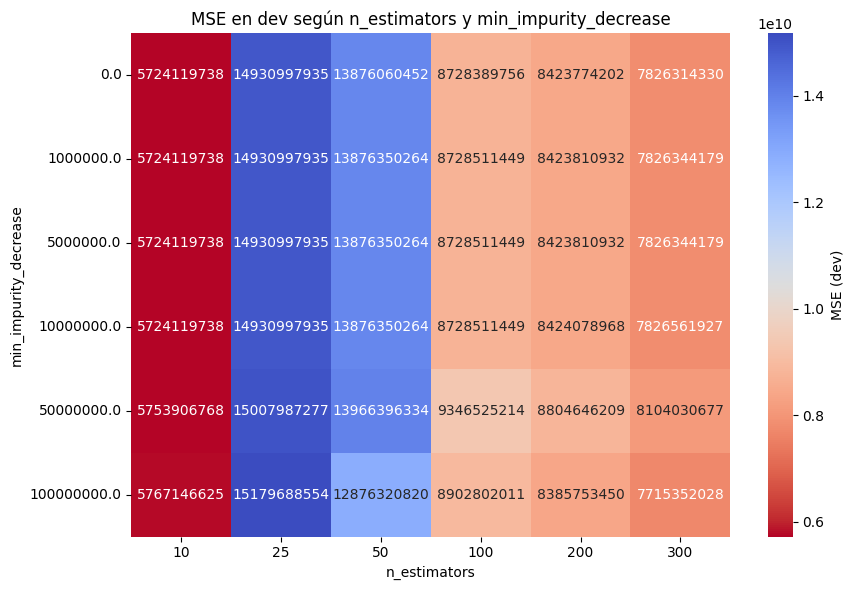

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Heatmap de MSE_dev por combinación de hiperparámetros ---
pivot = df_resultados.pivot(
    index="min_impurity_decrease",
    columns="n_estimators",
    values="MSE_dev"
)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm_r", cbar_kws={"label": "MSE (dev)"})
plt.title("MSE en dev según n_estimators y min_impurity_decrease")
plt.xlabel("n_estimators")
plt.ylabel("min_impurity_decrease")
plt.tight_layout()
plt.show()

### Interpretación del mapa de calor

---

### Interpretación del mapa de calor

El mapa de calor muestra un comportamiento no monótono del MSE en dev respecto a `n_estimators`. La configuración con 10 árboles presenta el menor error, con un MSE de aproximadamente 5.724.119.738, mientras que al aumentar a 25 árboles el error se incrementa considerablemente. A partir de 25 árboles, el MSE tiende a disminuir progresivamente conforme aumenta el número de estimadores, manteniéndose en valores más bajos y estables a partir de 100 árboles.

Este comportamiento debe interpretarse con cautela debido al reducido tamaño del conjunto de dev, compuesto únicamente por tres observaciones. En estas condiciones, el MSE puede ser muy sensible a las predicciones realizadas sobre cada observación, por lo que las diferencias entre configuraciones pueden no reflejar diferencias reales en su capacidad de generalización. En consecuencia, el hecho de que la configuración de 10 árboles obtenga el menor MSE en esta partición concreta no implica necesariamente que sea la configuración que mejor generalice ante nuevos datos.

En cuanto a `min_impurity_decrease`, se observa que los valores comprendidos entre 0 y 10.000.000 producen resultados muy similares para la mayoría de valores de `n_estimators`. El efecto del hiperparámetro comienza a ser más apreciable a partir de 50.000.000, modificando el MSE obtenido. Esto indica que los valores más elevados del hiperparámetro sí están afectando a las divisiones realizadas por los árboles y, por tanto, a la complejidad del modelo.

En conjunto, el mapa de calor pone de manifiesto la inestabilidad de la estimación del error en dev, derivada principalmente del reducido número de observaciones disponibles para la selección de hiperparámetros. Por ello, la configuración seleccionada debe considerarse la mejor dentro de la partición utilizada, pero no como evidencia concluyente de que sea la configuración óptima para generalizar a nuevos datos.

## Evaluación final en test

---

Una vez seleccionada la combinación óptima de hiperparámetros según el MSE en dev, se reentrena el modelo utilizando dicha combinación sobre el conjunto de train, y se evalúa su capacidad de generalización sobre el conjunto de test, que no ha sido utilizado en ninguna fase anterior del proceso (ni entrenamiento ni selección de hiperparámetros).

In [11]:
modelo_final = RandomForestRegressor(
    n_estimators=int(mejor["n_estimators"]),
    min_impurity_decrease=mejor["min_impurity_decrease"],
    random_state=RANDOM_STATE
)
modelo_final.fit(X_train, y_train)

pred_test = modelo_final.predict(X_test)
mse_test = mean_squared_error(y_test, pred_test)

print(f"MSE en test: {mse_test:.2f}")
print(f"RMSE en test: {np.sqrt(mse_test):.2f}")

MSE en test: 23814082256.50
RMSE en test: 154318.12


### Interpretación del resultado en test

---

El modelo obtiene un MSE de **23.814.082.256,50** en el conjunto de test, lo que corresponde a un RMSE de aproximadamente **154.318 unidades**. Comparando este error con el rango de la variable objetivo, situado entre **1.068.770 y 2.253.835 unidades matriculadas** durante el periodo analizado, el RMSE representa aproximadamente entre un **7 % y un 14 %** del volumen de ventas, dependiendo del año considerado.

Este resultado debe interpretarse teniendo en cuenta el reducido tamaño de la muestra y, especialmente, que el conjunto de test está formado únicamente por **4 observaciones**. Por tanto, el RMSE obtenido constituye una estimación con una elevada variabilidad y no permite extraer conclusiones definitivas sobre la capacidad de generalización del modelo.

El MSE obtenido en test es sensiblemente superior al mínimo obtenido en dev. Esta diferencia es coherente con el procedimiento seguido, ya que el conjunto de dev se utilizó para seleccionar la combinación de hiperparámetros con mejor rendimiento. En consecuencia, el modelo seleccionado está específicamente optimizado respecto a esas tres observaciones, mientras que el conjunto de test permanece independiente de este proceso y permite obtener una estimación más imparcial del rendimiento sobre datos no utilizados durante el desarrollo.

### Comparación entre valores reales y predichos

---

Para completar la evaluación del modelo, se representan gráficamente los valores reales de ventas frente a los valores predichos por el modelo en el conjunto de test, incluyendo la recta de predicción perfecta (y = x) como referencia visual.

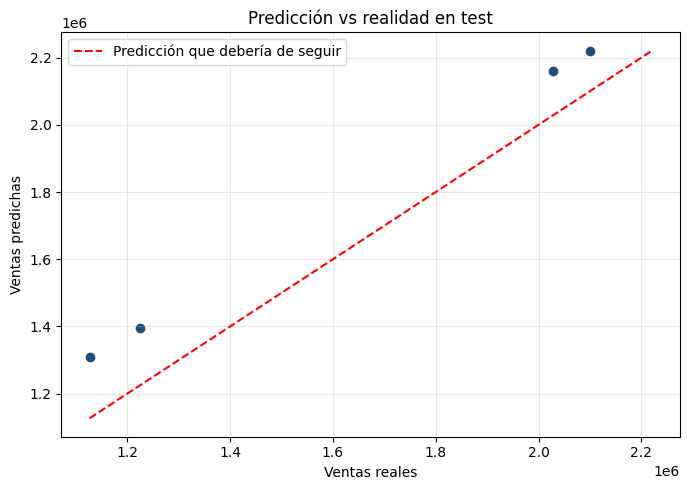

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_test, color="#1F4E79")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lims, lims, "r--", label="Predicción que debería de seguir")
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Predicción vs realidad en test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del gráfico de predicción vs. realidad

---

El gráfico muestra la relación entre las ventas reales y las ventas predichas por el modelo para las cuatro observaciones del conjunto de test. La línea roja discontinua representa la situación de **predicción perfecta**, en la que las ventas predichas coincidirían exactamente con las ventas reales.

Se observa que **las cuatro predicciones se sitúan por encima de la diagonal**, lo que indica que el modelo **sobreestima las ventas reales en todas las observaciones del conjunto de test**. La magnitud de esta sobreestimación varía según el año, siendo más elevada en las observaciones con menores niveles de ventas.

Este comportamiento puede estar relacionado con la capacidad limitada de las variables predictoras seleccionadas para recoger variaciones puntuales de la demanda. En particular, variables como `Population_Total` y `Compensation_Per_Employee` presentan una evolución creciente a lo largo del periodo analizado, por lo que pueden capturar parte de la tendencia estructural de las ventas, pero tienen una capacidad limitada para reflejar determinadas caídas puntuales de la demanda.

No obstante, dado que el conjunto de test está formado únicamente por **4 observaciones**, la presencia de sobreestimación en estas cuatro observaciones permite identificar un patrón en esta partición concreta aunque no se puede conocer si el modelo tendrá este mismo comportamiento en nuevos periodos.